# Black-Scholes Pricing

## Data

Use the option-chain data in `data/option_data_AMZN.xlsx`.

The file contains AMZN options as of the quote date in the `market data` sheet. The option chains are listed equity options; for this exercise, treat them as European options and ignore dividends.

In [ ]:
##import sys
##sys.path.insert(0, '../cmds')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# from options import *

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

In [ ]:
TICK = 'AMZN'
DATAFILE = f'./data/option_data_{TICK}.xlsx'

calls = pd.read_excel(DATAFILE, sheet_name='call chain')
puts = pd.read_excel(DATAFILE, sheet_name='put chain')
market = pd.read_excel(DATAFILE, sheet_name='market data').rename(columns={'Unnamed: 0': 'field'}).set_index('field')['data']

S = float(market.loc['equity price'])
rf = float(market.loc['Tbill'])
DATE = pd.to_datetime(market.loc['date'])
EXPRYDATE = pd.to_datetime(market.loc['option expiration'])
# tau = to_maturity(expiration=EXPRYDATE, current_date=DATE), ## Not usable, lack of option.py
tau = (EXPRYDATE - DATE).days / 365.0  # manual caluclation 

# focal strike: nearest to spot among strikes quoted in BOTH chains
K = 250  # focal strike (quoted in both chains; see prose)
SIGMA = 0.30

In [7]:
market_frame = pd.DataFrame(market).T
market_frame[['equity price', 'Tbill']] = market_frame[['equity price', 'Tbill']].astype(float)
market_frame.style.format({'equity price': '${:,.2f}', 'Tbill': '{:.2%}'})

field,ticker,equity price,Tbill,date,option expiration
data,AMZN,$245.22,3.68%,2026-06-08,2026-07-17


In [8]:
option_pair = pd.concat(
    {
        'call': calls.set_index('strike').loc[K, ['lastPrice', 'bid', 'ask', 'impliedVolatility', 'volume', 'openInterest']],
        'put': puts.set_index('strike').loc[K, ['lastPrice', 'bid', 'ask', 'impliedVolatility', 'volume', 'openInterest']],
    },
    axis=1,
).T

option_pair.style.format({
    'lastPrice': '${:,.2f}',
    'bid': '${:,.2f}',
    'ask': '${:,.2f}',
    'impliedVolatility': '{:.2%}',
    'volume': '{:,.0f}',
    'openInterest': '{:,.0f}',
})

,lastPrice,bid,ask,impliedVolatility,volume,openInterest
call,$8.62,$8.50,$8.70,32.07%,"1,283","6,050"
put,$12.27,$12.05,$12.45,32.04%,419,"7,110"


# 1. Option Chain

### 1.1.
For the expiration in the data file, plot the market quoted prices of the puts and calls across strikes.

Use `lastPrice` for the market option price.

### 1.2.
Make the same plot, but use quoted `impliedVolatility` rather than market price.

### 1.3.
What are the main differences between the price plot and the implied-volatility plot? What should you be careful about when interpreting the far out-of-the-money options?

**Answer:** Option prices are always expected to be higher for higher strike price for **puts**, and lower for higher strike price for **calls** so the shape is almost always consistent reflecting the option contract's intrinsic value and moneyness. But implied volatilityt v. strike shows that IV is lowest near the at-the-money strikes and higher for low-strike downside options, reflecting the market’s greater pricing of downside risk. 

Far out-of-the-money options should be interpreted carefully because their prices and Vega are very small. Consequently, wide bid–ask spreads or low trading volume can produce large and unreliable changes in calculated implied volatility using B-S model.

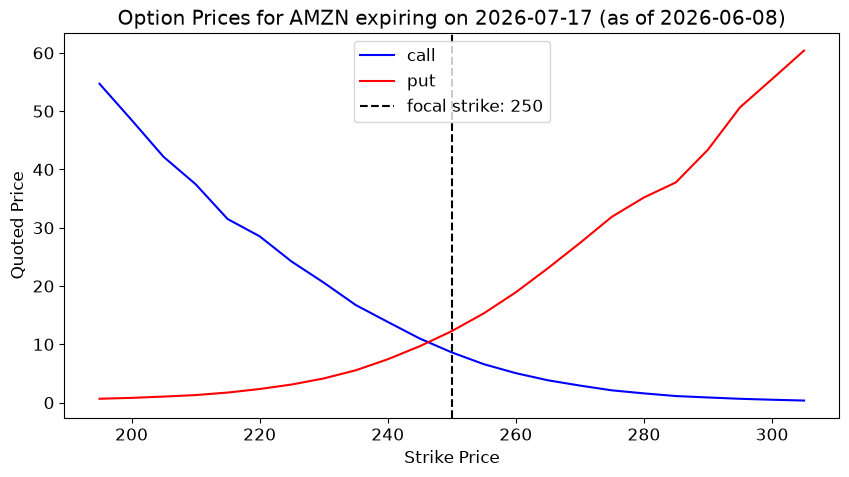

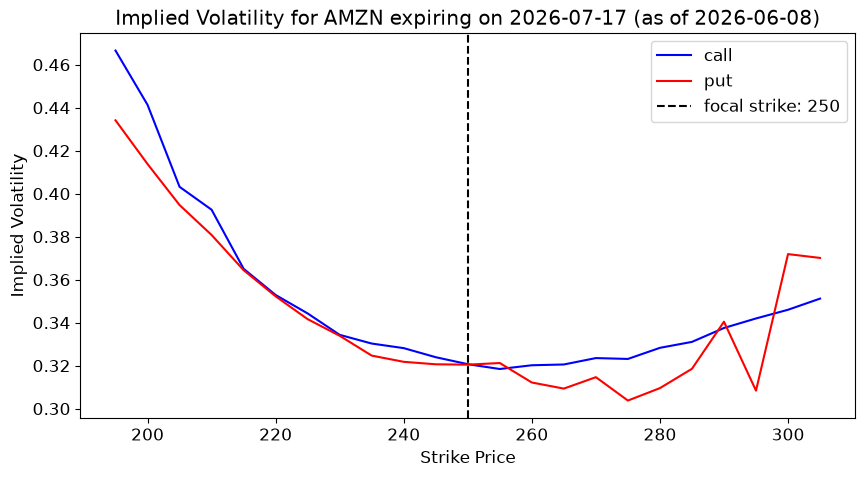

In [14]:
# 1.1 plot quoted prices across strikes for both calls and puts, with focal strike highlighted
plt.plot(calls['strike'], calls['lastPrice'], label='call', color='blue')
plt.plot(puts['strike'], puts['lastPrice'], label='put', color='red')
plt.axvline(x=K, color='black', linestyle='--', label=f'focal strike: {K}')
plt.xlabel('Strike Price')
plt.ylabel('Quoted Price')
plt.title(f'Option Prices for {TICK} expiring on {EXPRYDATE.date()} (as of {DATE.date()})')
plt.legend()
plt.show()

# 1.2 plot IV against market price
plt.plot(calls['strike'], calls['impliedVolatility'], label='call', color='blue')
plt.plot(puts['strike'], puts['impliedVolatility'], label='put', color='red')
plt.axvline(x=K, color='black', linestyle='--', label   =f'focal strike: {K}')      
plt.xlabel('Strike Price')
plt.ylabel('Implied Volatility')
plt.title(f'Implied Volatility for {TICK} expiring on {EXPRYDATE.date()} (as of {DATE.date()})')
plt.legend()
plt.show()

***

# 2. Black-Scholes Values

Focus on the strike `K = 250`, with expiration equal to the option expiration in the data file.

### 2.1.
Using annualized volatility `SIGMA = 30%`, calculate the Black-Scholes value of the call and the put.

### 2.2.
Compare the Black-Scholes values to the listed `lastPrice` market quotes. Does `30%` look too high or too low relative to the market prices?

### 2.3.
Plot the Black-Scholes value of the call against the stock price, holding time-to-maturity, the risk-free rate, and volatility fixed.

Describe how the slope of the curve changes as the option moves from out-of-the-money to in-the-money.

In [19]:
#2.1 compute call and put prices using Black-Scholes formula

# Create custom functions for now 
from scipy.stats import norm

def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def black_scholes_put(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

K = 250
SIGMA = 0.30

call = black_scholes_call(S, K, tau, rf, SIGMA)
put = black_scholes_put(S, K, tau, rf, SIGMA)

print(f"Black-Scholes call value: ${call:.2f}")
print(f"Black-Scholes put value:  ${put:.2f}")

#2.2 compare to market prices
print(f"Market call price: ${calls[calls['strike'] == K]['lastPrice'].values[0]:.2f}")
print(f"Market put price:  ${puts[puts['strike'] == K]['lastPrice'].values[0]:.2f}")

Black-Scholes call value: $7.88
Black-Scholes put value:  $11.68
Market call price: $8.62
Market put price:  $12.27


**Answer:** Since the quoted market prices are higher for both the call and put 07/17/26 @ 250, the assumed 30% annualized volatility is too low, or underestimated compared to the IV.

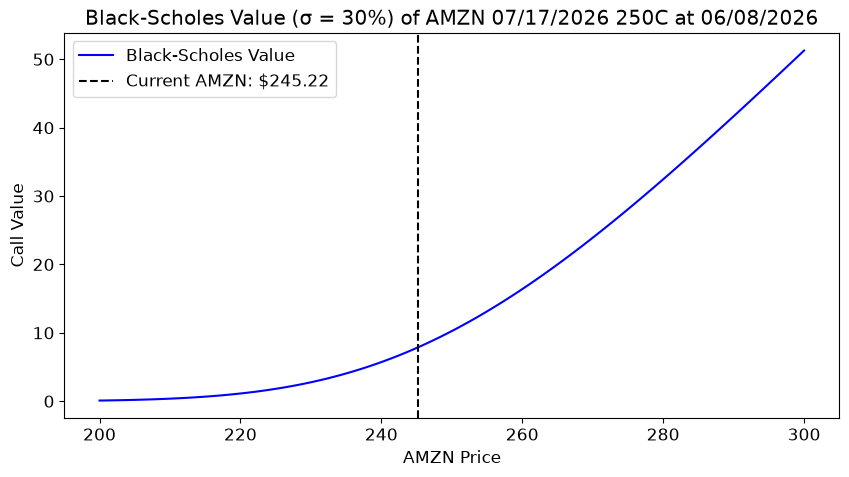

In [26]:
#2.3 Plot the Black-Scholes value of the call against the stock price, holding time-to-maturity, the risk-free rate, and volatility fixed.
plt.figure(figsize=(10, 5))
S_range = np.linspace(200, 300, 100)
call_prices = [black_scholes_call(S, K, tau, rf, SIGMA) for S in S_range]
plt.plot(S_range, call_prices, label='Black-Scholes Value', color='blue')
plt.axvline(x=S, color='black', linestyle='--', label=f'Current AMZN: ${S:.2f}')
plt.xlabel('AMZN Price')
plt.ylabel('Call Value')
plt.title('Black-Scholes Value (σ = 30%) of AMZN 07/17/2026 250C at 06/08/2026')
plt.legend()
plt.show()

**Answer:** The slope of the curve, when the underlying stock price increases from OTM to ITM, increases sharply, as Gamma is highest when the option is ATM. But as AMZN moves higher into Deep ITM zones, the slope increase slow down and eventually becomes nearly linear, as **Gamma becomes nearly 0 and Delta approaches 1.**

***

# 3. Implied Volatility and Greeks

### 3.1.
Instead of assuming a volatility, use the market `lastPrice` to solve for the implied volatility of the call and the put at `K = 250`.

Compare your calculated implied volatilities to the quoted `impliedVolatility` values in the data.

### 3.2.
Using the implied volatility from the call, calculate the call's Delta, Gamma, Vega, and daily Theta.

### 3.3.
Reprice the call for volatilities from `20%` to `40%` in `5%` increments. How sensitive is the option value to volatility at this strike and maturity?